# Face Recognition Attendance System


- Built using OpenCV, face_recognition, SQLite, and FastAPI. 

* _please watch the demonstration video provided below for a better understanding of this project_


#### Realtime Face Recognition :
[![face recognition](https://img.youtube.com/vi/3-MxA6PT-VA/0.jpg)](https://www.youtube.com/watch?v=3-MxA6PT-VA)


#### Attendance System :


[![face recognition](https://img.youtube.com/vi/zvS3_DIxHZM/0.jpg)](https://www.youtube.com/watch?v=zvS3_DIxHZM)


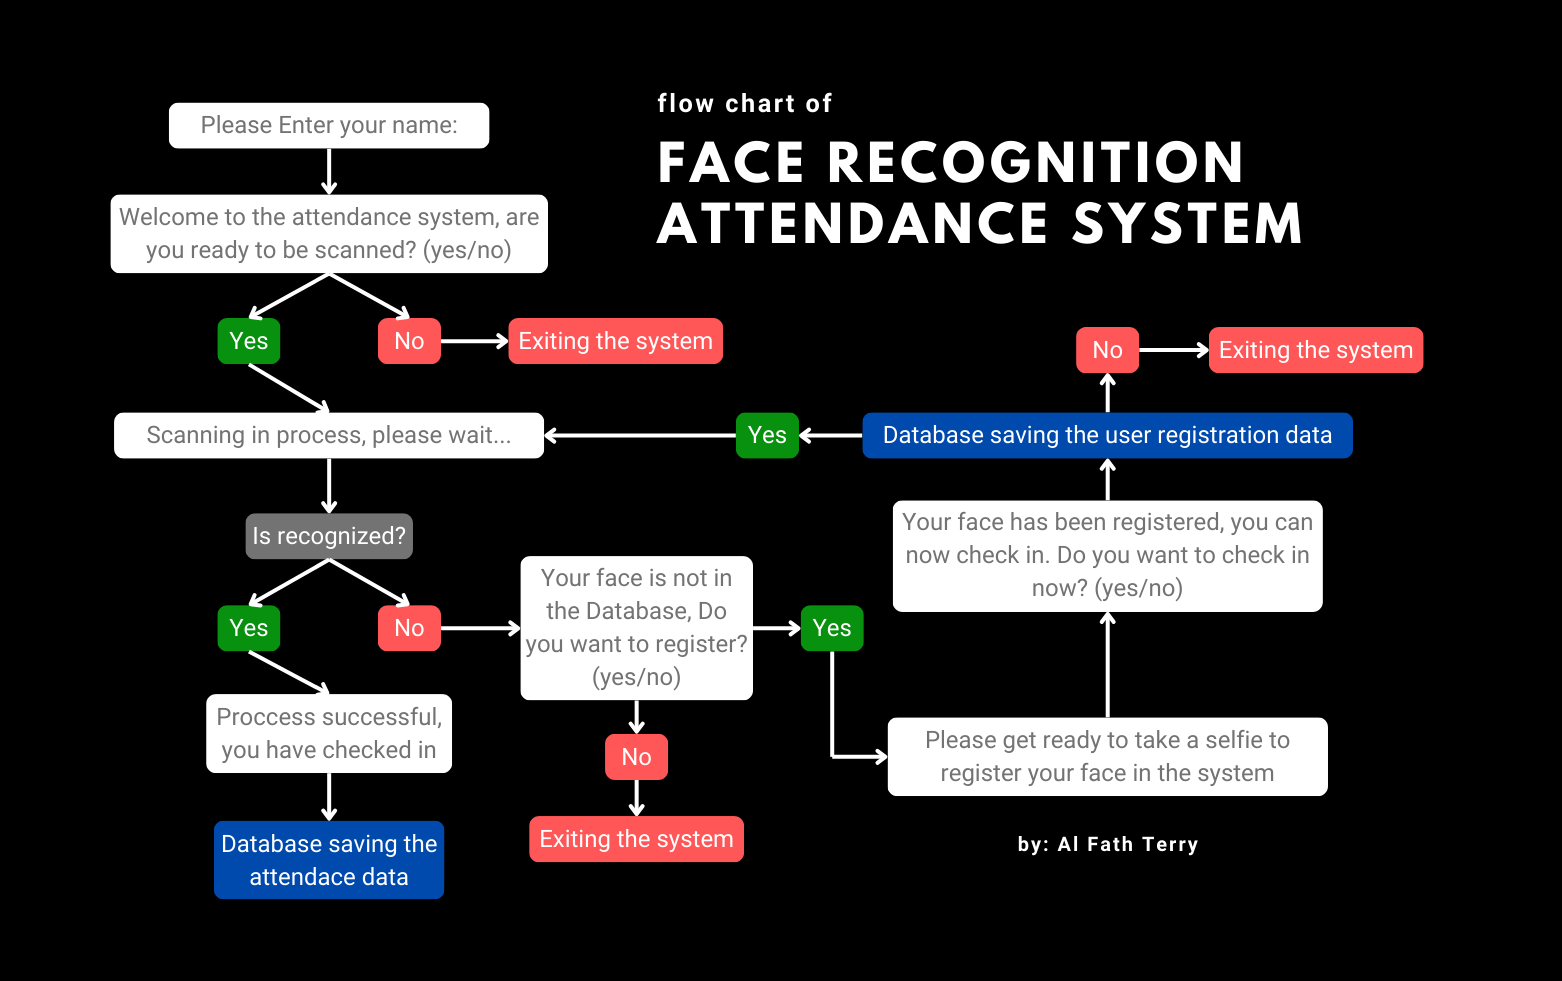


## Key Features

- Face recognition for user authentication
- SQLite database for storing user and attendance information
- FastAPI for creating API endpoints to fetch user and attendance data

## Prerequisites

- Python 3.7+
- `pip` (Python package installer)

## Setup Instructions



### Step 1: Create a Virtual Environment

Create a virtual environment to manage dependencies:

``` bash
python -m venv venv
source venv/bin/activate  # On Windows, use `venv\Scripts\activate`
```

### Step 2: Install Dependencies

Install the required dependencies using pip:

``` bash
pip install -r requirements.txt
```

### Step 3: Initialize the Database

Run the script to initialize the SQLite database:

``` bash
python database.py
```

### Step 4: Run the Attendance System

To start the attendance system, run the following command:

``` bash
python attendance_system.py
```

### Step 5: Use the FastAPI Application

Run the FastAPI application to access the API endpoints:

```
uvicorn main:app --reload
```

Access the API documentation at 'http://127.0.0.1:8000/docs'


In [1]:
import os
import sys
import cv2
import numpy as np
import face_recognition
import math
import matplotlib.pyplot as plt
import time
from database import add_face_recognition
from datetime import datetime 
from PIL import Image
import ollama
#import mediapipe as mp
import sqlite3

# Python (Face Recognition Attendance System)

In [3]:

import os
import sys
import cv2
import numpy as np
import face_recognition
import math
import matplotlib.pyplot as plt
import time
from database import add_face_recognition
from datetime import datetime 

class FaceRecognition:
    def __init__(self):
        self.face_locations = [] 
        self.face_encodings = []
        self.face_names = []
        self.known_face_encodings = []
        self.known_face_names = []
        self.process_current_frame = True
        self.encode_faces()

    def encode_faces(self):
        for image in os.listdir('static/faces'):
            if image == '.DS_Store':
                continue
            face_image = face_recognition.load_image_file(f'static/faces/{image}')
            face_encoding = face_recognition.face_encodings(face_image)[0]
            self.known_face_encodings.append(face_encoding)
            self.known_face_names.append(image.split('.')[0])

    def face_confidence(self, face_distance, face_match_threshold=0.6):
        range_var = (1.0 - face_match_threshold)
        linear_val = (1.0 - face_distance) / (range_var * 2.0)

        if face_distance > face_match_threshold: 
            return f"{round(linear_val * 100, 2)}%"
        else:
            value = (linear_val + ((1.0 - linear_val) * math.pow((linear_val - 0.5) * 2, 0.2))) * 100
            return f"{round(value, 2)}%"

    def prompt_ready(self):
        response = input("Welcome to the attendance system, are you ready to be scanned? (yes/no): ").strip().lower()
        return response == 'yes'

    def run_recognition(self):
        video_capture = cv2.VideoCapture(0)

        if not video_capture.isOpened():
            sys.exit('Video not found')

        recognized = False
        last_frame = None
        start_time = time.time()

        while not recognized and (time.time() - start_time) < 5: 
            print("Scanning in process, please wait...")  
            ret, frame = video_capture.read()
            if not ret:
                break

            if self.process_current_frame:
                small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
                rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)
                self.face_locations = face_recognition.face_locations(rgb_small_frame)
                self.face_encodings = face_recognition.face_encodings(rgb_small_frame, self.face_locations)

                self.face_names = []
                for face_encoding in self.face_encodings:
                    matches = face_recognition.compare_faces(self.known_face_encodings, face_encoding)
                    name = 'unknown'
                    confidence = 'unknown'

                    face_distances = face_recognition.face_distance(self.known_face_encodings, face_encoding)
                    best_match_index = np.argmin(face_distances)

                    if matches[best_match_index]:
                        name = self.known_face_names[best_match_index]
                        confidence = self.face_confidence(face_distances[best_match_index])
                        if float(confidence[:-1]) > 95.0:
                            recognized = True

                    self.face_names.append(f'{name} ({confidence})')
            
            self.process_current_frame = not self.process_current_frame

            if recognized:
                last_frame = frame.copy()
                break

        video_capture.release()
        cv2.destroyAllWindows() 

        if last_frame is not None:
            self.plot_recognized_face(last_frame)

        return recognized

    def plot_recognized_face(self, frame):
        for (top, right, bottom, left), name in zip(self.face_locations, self.face_names):
            top *= 4
            right *= 4 
            bottom *= 4
            left *= 4

            cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 4)
            cv2.rectangle(frame, (left, bottom - 50), (right, bottom), (0, 0, 255), -2)
            cv2.putText(frame, name, (left + 6, bottom - 6), cv2.FONT_HERSHEY_DUPLEX, 2, (255, 255, 255), 1)

            face_landmarks_list = face_recognition.face_landmarks(frame)
            for face_landmarks in face_landmarks_list:
                for facial_feature in face_landmarks.keys():
                    for point in face_landmarks[facial_feature]:
                        cv2.circle(frame, point, 2, (0, 255, 255), -1)

        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title("Recognized Face")
        plt.axis('off')
        plt.show()

        self.plot_color_histogram(frame)

    def plot_color_histogram(self, frame):
        color = ('b', 'g', 'r')
        plt.figure(figsize=(10, 5)) 
        for i, col in enumerate(color): 
            hist = cv2.calcHist([frame], [i], None, [256], [0, 256])
            plt.plot(hist, color=col)
            plt.xlim([0, 256])
        plt.title("Histogram for color scale picture")
        plt.show()

    def take_selfie(self, your_name):
        print("Please get ready to take a selfie to register your face in the system.")
        video_capture = cv2.VideoCapture(0)
        if not video_capture.isOpened():
            sys.exit('Video not found')

        while True:
            ret, frame = video_capture.read()
            if not ret:
                break

            cv2.imshow('Press "S" to take a Selfie and Exit', frame)
            if cv2.waitKey(1) & 0xFF == ord('s'):
                cv2.imwrite(f'static/faces/{your_name}.png', frame)
                cv2.destroyAllWindows()
                break

        video_capture.release()
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"{your_name}")
        plt.axis('off')
        plt.show()

        self.encode_faces()

class AttendanceSystem:
    def __init__(self):
        self.face_recognition = FaceRecognition()
        self.user_name = ""

    def start(self):
        self.user_name = input("Please enter your name: ").strip()
        if not self.face_recognition.prompt_ready():
            print("Exiting the system.")
            return
        self.scan_and_check_in()

    def scan_and_check_in(self):
        recognized = self.face_recognition.run_recognition()
        if recognized:
            print("Attendance recorded successfully.")
            add_attendance(self.user_name) # record attendance to database
        else:
            response = input("Your face is not in the database. Do you want to register? (yes/no): ").strip().lower()
            if response == 'yes':
                self.face_recognition.take_selfie(self.user_name)
                print(f"Your face has been registered, {self.user_name}. You can now check in.")
                regist_user(self.user_name) # regist to database
                response = input("Do you want to check in now? (yes/no): ").strip().lower()
                if response == 'yes':
                    self.scan_and_check_in()
            else:
                print("Exiting the system.")

if __name__ == "__main__":
    system = AttendanceSystem()
    system.start()


Exiting the system.


# Realtime Face Recognition

In [ ]:

import os
import sys
import math
import cv2
import numpy as np
import face_recognition
from database import add_face_recognition  # Thêm dòng này để gọi hàm ghi CSDL


class FaceRecognitionRealTime:
    def __init__(self, face_match_threshold=0.5):
        self.face_locations = []
        self.face_encodings = []
        self.face_names = []
        self.known_face_encodings = []
        self.known_face_names = []
        self.process_current_frame = True
        self.face_match_threshold = face_match_threshold
        self.encode_faces()
        self.already_checked_in = set()  # Để tránh điểm danh trùng

    def encode_faces(self):
        os.makedirs('static/faces_realtime', exist_ok=True)
        for image_name in os.listdir('static/faces_realtime'):
            if image_name.startswith('.'):
                continue
            image_path = os.path.join('static/faces_realtime', image_name)
            image = face_recognition.load_image_file(image_path)
            encodings = face_recognition.face_encodings(image)
            if encodings:
                self.known_face_encodings.append(encodings[0])
                self.known_face_names.append(os.path.splitext(image_name)[0])

    def face_confidence(self, face_distance):
        if face_distance > self.face_match_threshold:
            return "0%"
        else:
            range_val = (1.0 - self.face_match_threshold)
            linear_val = (1.0 - face_distance) / (range_val * 2.0)
            confidence = (linear_val + ((1.0 - linear_val) * math.pow((linear_val - 0.5) * 2, 0.2))) * 100
            return f"{round(confidence, 2)}%"

    def run_recognition_realtime(self):
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            sys.exit("Cannot open camera")

        while True:
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame")
                break

            frame = cv2.flip(frame, 1)

            if self.process_current_frame:
                small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
                rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

                self.face_locations = face_recognition.face_locations(rgb_small_frame)
                self.face_encodings = face_recognition.face_encodings(rgb_small_frame, self.face_locations)

                self.face_names = []
                for face_encoding in self.face_encodings:
                    if not self.known_face_encodings:
                        self.face_names.append("unknown (0%)")
                        continue

                    face_distances = face_recognition.face_distance(self.known_face_encodings, face_encoding)
                    best_match_index = np.argmin(face_distances)
                    best_distance = face_distances[best_match_index]

                    if best_distance <= self.face_match_threshold:
                        name_raw = self.known_face_names[best_match_index]
                        confidence = self.face_confidence(best_distance)

                        try:
                            ten, user_id_str, lecture_id_str = name_raw.split('-')
                            user_id = int(user_id_str)
                            lecture_id = int(lecture_id_str)
                            name_display = f"{ten} ({confidence})"
                            self.face_names.append(name_display)

                            key = (user_id, lecture_id)
                            if key not in self.already_checked_in:
                                add_face_recognition(ten, user_id, lecture_id)
                                self.already_checked_in.add(key)
                        except ValueError:
                            self.face_names.append("FormatError (0%)")
                    else:
                        self.face_names.append("unknown (0%)")

            self.process_current_frame = not self.process_current_frame

            for (top, right, bottom, left), name in zip(self.face_locations, self.face_names):
                top *= 4
                right *= 4
                bottom *= 4
                left *= 4

                cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
                cv2.rectangle(frame, (left, bottom - 35), (right, bottom), (0, 0, 255), cv2.FILLED)
                cv2.putText(frame, name, (left + 6, bottom - 6),
                            cv2.FONT_HERSHEY_DUPLEX, 0.8, (255, 255, 255), 1)

            cv2.imshow('Face Recognition (Press "Q" to exit)', frame)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()
        
def run_once_and_return_result(app=None, max_attempts=100, show_window=False):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        return {"status": "error", "message": "Cannot open camera"}

    if app is None:
        app = FaceRecognitionRealTime()

    result = []
    attempts = 0

    while attempts < max_attempts:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
        rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        face_locations = face_recognition.face_locations(rgb_small_frame)
        face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations)

        for face_encoding in face_encodings:
            face_distances = face_recognition.face_distance(app.known_face_encodings, face_encoding)
            best_match_index = np.argmin(face_distances)
            best_distance = face_distances[best_match_index]

            if best_distance <= app.face_match_threshold:
                try:
                    name_raw = app.known_face_names[best_match_index]
                    ten, user_id_str, lecture_id_str = name_raw.split('-')
                    user_id = int(user_id_str)
                    lecture_id = int(lecture_id_str)

                    key = (user_id, lecture_id)
                    if key not in app.already_checked_in:
                        add_face_recognition(ten, user_id, lecture_id)
                        app.already_checked_in.add(key)

                    cap.release()
                    cv2.destroyAllWindows()
                    return {
                        "status": "success",
                        "ten": ten,
                        "user_id": user_id,
                        "lecture_id": lecture_id
                    }
                except Exception as e:
                    return {"status": "error", "message": str(e)}

        if show_window:
            cv2.imshow("Checking...", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        attempts += 1

    cap.release()
    cv2.destroyAllWindows()
    return {"status": "not_found", "message": "Không nhận diện được khuôn mặt"}

if __name__ == "__main__":
    app = FaceRecognitionRealTime()
    app.run_recognition_realtime()


In [ ]:
"""
import os
import sys
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
import face_recognition


class FaceRecognitionRealTime:
    def __init__(self, face_match_threshold=0.5):
        # Biến lưu trữ vị trí khuôn mặt, mã hóa, tên người đã biết
        self.face_locations = []
        self.face_encodings = []
        self.face_names = []
        self.known_face_encodings = []
        self.known_face_names = []
        self.process_current_frame = True
        # Ngưỡng khoảng cách khuôn mặt để nhận diện chính xác
        self.face_match_threshold = face_match_threshold
        # Load ảnh khuôn mặt đã lưu và mã hóa
        self.encode_faces()

    def encode_faces(self):
        # Tạo thư mục lưu ảnh khuôn mặt nếu chưa có
        os.makedirs('static/faces_realtime', exist_ok=True)
        for image_name in os.listdir('static/faces_realtime'):
            if image_name.startswith('.'):
                continue
            image_path = os.path.join('static/faces_realtime', image_name)
            image = face_recognition.load_image_file(image_path)
            encodings = face_recognition.face_encodings(image)
            if encodings:
                self.known_face_encodings.append(encodings[0])
                self.known_face_names.append(os.path.splitext(image_name)[0])

    def face_confidence(self, face_distance):
        #Tính phần trăm độ tin cậy khuôn mặt dựa trên khoảng cách
        if face_distance > self.face_match_threshold:
            return "0%"
        else:
            range_val = (1.0 - self.face_match_threshold)
            linear_val = (1.0 - face_distance) / (range_val * 2.0)
            confidence = (linear_val + ((1.0 - linear_val) * math.pow((linear_val - 0.5) * 2, 0.2))) * 100
            return f"{round(confidence, 2)}%"

    def run_recognition_realtime(self):
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            sys.exit("Cannot open camera")

        while True:
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame")
                break

            frame = cv2.flip(frame, 1)

            if self.process_current_frame:
                # Thu nhỏ khung hình để tăng tốc
                small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
                rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

                # Tìm vị trí và mã hóa khuôn mặt trong khung nhỏ
                self.face_locations = face_recognition.face_locations(rgb_small_frame)
                self.face_encodings = face_recognition.face_encodings(rgb_small_frame, self.face_locations)

                self.face_names = []
                for face_encoding in self.face_encodings:
                    if not self.known_face_encodings:
                        # Nếu database trống, luôn là unknown
                        self.face_names.append("unknown (0%)")
                        continue

                    # Tính khoảng cách giữa face_encoding và tất cả khuôn mặt đã biết
                    face_distances = face_recognition.face_distance(self.known_face_encodings, face_encoding)
                    best_match_index = np.argmin(face_distances)
                    best_distance = face_distances[best_match_index]

                    # So sánh khoảng cách với ngưỡng để quyết định nhận diện
                    if best_distance <= self.face_match_threshold:
                        name = self.known_face_names[best_match_index]
                        confidence = self.face_confidence(best_distance)
                    else:
                        name = "unknown"
                        confidence = "0%"

                    self.face_names.append(f"{name} ({confidence})")

            self.process_current_frame = not self.process_current_frame

            # Vẽ hình chữ nhật và tên lên khung hình gốc
            for (top, right, bottom, left), name in zip(self.face_locations, self.face_names):
                top *= 4
                right *= 4
                bottom *= 4
                left *= 4

                cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
                cv2.rectangle(frame, (left, bottom - 35), (right, bottom), (0, 0, 255), cv2.FILLED)
                cv2.putText(frame, name, (left + 6, bottom - 6),
                            cv2.FONT_HERSHEY_DUPLEX, 0.8, (255, 255, 255), 1)

            cv2.imshow('Face Recognition (Press "Q" to exit)', frame)

            # Nhấn 'q' để thoát
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()


if __name__ == "__main__":
    app = FaceRecognitionRealTime()
    app.run_recognition_realtime()
"""